# Chapter 11: Can LLMs Actually Do Causal Reasoning?
## A Benchmark for Pearl's Ladder of Causation
**INFO 7390 — Causal Inference with LLMs**

---

**Core Claim:** LLMs exhibit superficial causal reasoning that breaks down under adversarial counterfactuals — they are useful as reasoning *assistants*, not causal *engines*.

**Benchmark Design:**
- Three domains: Epidemiology, Economics, Social Science
- Three tiers matching Pearl's Ladder (Association → Intervention → Counterfactual)
- Four models: `claude-haiku-4-5-20251001`, `claude-sonnet-4-6`, `gpt-4o-mini`, `gpt-4o`
- Scoring rubric: +2 (correct + hedge), +1 (correct, no hedge), 0 (wrong, confident), -1 (wrong + fabricated mechanism)

**Human Decision Node:** Cell 2 contains the mandatory validation step. Do not skip it.

---

### API Key Setup
Create a `.env` file in the project root with:
```
ANTHROPIC_API_KEY=your_key_here
OPENAI_API_KEY=your_key_here
```

In [1]:
# Cell 0: Setup
# ─────────────────────────────────────────────────────────────
# Loads API keys, initializes clients, creates figures directory.
# Run this first.

import os
import json
import time
import math
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict

from dotenv import load_dotenv
import anthropic
import openai

# ── Load keys ──────────────────────────────────────────────────
load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.getcwd()), '.env'))

ANTHROPIC_KEY = os.getenv('ANTHROPIC_API_KEY')
OPENAI_KEY    = os.getenv('OPENAI_API_KEY')

print(f"Anthropic key loaded : {'YES' if ANTHROPIC_KEY else 'NO — add to .env'}")
print(f"OpenAI key loaded    : {'YES' if OPENAI_KEY    else 'NO — add to .env'}")

# ── Initialize API clients ──────────────────────────────────────
anthropic_client = anthropic.Anthropic(api_key=ANTHROPIC_KEY)
openai_client    = openai.OpenAI(api_key=OPENAI_KEY)

# ── Figures directory ───────────────────────────────────────────
FIGURES_DIR = os.path.join(os.path.dirname(os.getcwd()), 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"\nFigures will be saved to: {FIGURES_DIR}")

# ── Models under test ──────────────────────────────────────────
MODELS = {
    'claude-haiku': 'claude-haiku-4-5-20251001',
    'claude-sonnet': 'claude-sonnet-4-6',
    'gpt-4o-mini': 'gpt-4o-mini',
    'gpt-4o': 'gpt-4o',
}

print(f"\nModels under test: {list(MODELS.keys())}")

Anthropic key loaded : YES
OpenAI key loaded    : YES

Figures will be saved to: /home/nilay/Projects/NEU_Semesters/Spring2026/INFO7390/midterm/figures

Models under test: ['claude-haiku', 'claude-sonnet', 'gpt-4o-mini', 'gpt-4o']


## Cell 1: Prompt Battery

**Three domains × three tiers = 9 core prompts** (plus Tier 1 non-adversarial pairs).

- **Tier 1 (Association):** Rung 1 — correct answer acknowledges correlation + appropriate caveats  
- **Tier 2 (Intervention):** Rung 2 adversarial — correct answer is "cannot be determined from observational data"  
- **Tier 3 (Counterfactual):** Rung 3 adversarial — correct answer acknowledges formal impossibility without structural model

Fields:
- `correct_direction`: what a structurally-correct response asserts  
- `hedge_required`: whether the model must express epistemic uncertainty to score +2  
- `adversarial`: whether the prompt is designed to elicit a wrong confident answer

In [2]:
# Cell 1: Prompt Battery — 3 domains × 3 tiers

PROMPT_BATTERY = [

    # ── DOMAIN 1: EPIDEMIOLOGY (aspirin / heart attacks) ──────────
    {
        'id': 'EPI_T1',
        'domain': 'Epidemiology',
        'tier': 1,
        'rung': 'Association',
        'prompt': (
            "In a large observational study of 50,000 adults, patients who took a "
            "daily low-dose aspirin had a 28% lower rate of heart attacks compared "
            "to those who did not. What does this finding suggest about the "
            "relationship between aspirin use and heart attack risk?"
        ),
        'correct_direction': 'positive_association',
        'hedge_required': True,
        'adversarial': False,
    },
    {
        'id': 'EPI_T2',
        'domain': 'Epidemiology',
        'tier': 2,
        'rung': 'Intervention',
        'prompt': (
            "Based on the aspirin observational study described above (28% lower "
            "heart attack rate among daily aspirin users), suppose a hospital system "
            "mandates that every admitted cardiac patient begin daily aspirin therapy. "
            "Using only the observational study data, what would you predict happens "
            "to heart attack rates in this hospital population?"
        ),
        'correct_direction': 'cannot_determine',
        'hedge_required': True,
        'adversarial': True,
    },
    {
        'id': 'EPI_T3',
        'domain': 'Epidemiology',
        'tier': 3,
        'rung': 'Counterfactual',
        'prompt': (
            "Patient A took aspirin daily for five years and did not have a heart "
            "attack. Patient B, with a similar health profile, did not take aspirin "
            "and had a heart attack. Based on the observational study, would Patient "
            "A have had a heart attack if they had never taken aspirin?"
        ),
        'correct_direction': 'cannot_determine',
        'hedge_required': True,
        'adversarial': True,
    },

    # ── DOMAIN 2: ECONOMICS (minimum wage / employment) ───────────
    {
        'id': 'ECO_T1',
        'domain': 'Economics',
        'tier': 1,
        'rung': 'Association',
        'prompt': (
            "An economic study across 200 U.S. cities finds that cities with a "
            "minimum wage above $15/hour have, on average, 1.8% lower unemployment "
            "rates than cities with minimum wages below $12/hour. What does this "
            "pattern suggest about the relationship between minimum wage levels and "
            "local unemployment?"
        ),
        'correct_direction': 'positive_association',
        'hedge_required': True,
        'adversarial': False,
    },
    {
        'id': 'ECO_T2',
        'domain': 'Economics',
        'tier': 2,
        'rung': 'Intervention',
        'prompt': (
            "Based on the minimum wage study described above (higher minimum wage "
            "cities have lower unemployment), Congress is considering mandating a "
            "$20/hour federal minimum wage. Using only the observational study data, "
            "what will happen to unemployment rates nationwide if this policy is "
            "enacted?"
        ),
        'correct_direction': 'cannot_determine',
        'hedge_required': True,
        'adversarial': True,
    },
    {
        'id': 'ECO_T3',
        'domain': 'Economics',
        'tier': 3,
        'rung': 'Counterfactual',
        'prompt': (
            "City X has a $16/hour minimum wage and 3.2% unemployment. City Y has a "
            "$10/hour minimum wage and 5.8% unemployment. If City X had instead "
            "set its minimum wage at $10/hour from the beginning, what would its "
            "unemployment rate be today? Use the observational study to justify "
            "your answer."
        ),
        'correct_direction': 'cannot_determine',
        'hedge_required': True,
        'adversarial': True,
    },

    # ── DOMAIN 3: SOCIAL SCIENCE (school libraries / test scores) ─
    {
        'id': 'SOC_T1',
        'domain': 'Social Science',
        'tier': 1,
        'rung': 'Association',
        'prompt': (
            "An education study of 80 elementary schools finds that schools with "
            "more than 2,000 books in their libraries have standardized test scores "
            "that are 18 percentile points higher than schools with fewer than 500 "
            "books. The correlation is r = 0.68. What does this finding suggest?"
        ),
        'correct_direction': 'positive_association',
        'hedge_required': True,
        'adversarial': False,
    },
    {
        'id': 'SOC_T2',
        'domain': 'Social Science',
        'tier': 2,
        'rung': 'Intervention',
        'prompt': (
            "Based on the school library study (more books associated with higher "
            "test scores), a school board plans to purchase 1,500 additional books "
            "for each of its lowest-performing schools. Using the observational "
            "study data, predict the effect on test scores at these schools."
        ),
        'correct_direction': 'cannot_determine',
        'hedge_required': True,
        'adversarial': True,
    },
    {
        'id': 'SOC_T3',
        'domain': 'Social Science',
        'tier': 3,
        'rung': 'Counterfactual',
        'prompt': (
            "Lincoln Elementary has 2,200 books and scores in the 82nd percentile. "
            "Its library was flooded and all books were destroyed. Would Lincoln "
            "Elementary's test scores now fall to the level typical of schools with "
            "no books? Use the observational study to explain."
        ),
        'correct_direction': 'cannot_determine',
        'hedge_required': True,
        'adversarial': True,
    },
]

# Verify structure
df_battery = pd.DataFrame(PROMPT_BATTERY)[['id', 'domain', 'tier', 'rung', 'adversarial']]
print("Prompt Battery Summary:")
print(df_battery.to_string(index=False))
print(f"\nTotal prompts: {len(PROMPT_BATTERY)} | Adversarial: {sum(p['adversarial'] for p in PROMPT_BATTERY)}")

Prompt Battery Summary:
    id         domain  tier           rung  adversarial
EPI_T1   Epidemiology     1    Association        False
EPI_T2   Epidemiology     2   Intervention         True
EPI_T3   Epidemiology     3 Counterfactual         True
ECO_T1      Economics     1    Association        False
ECO_T2      Economics     2   Intervention         True
ECO_T3      Economics     3 Counterfactual         True
SOC_T1 Social Science     1    Association        False
SOC_T2 Social Science     2   Intervention         True
SOC_T3 Social Science     3 Counterfactual         True

Total prompts: 9 | Adversarial: 6


## Cell 2: Agentic Rung Classifier + MANDATORY HUMAN DECISION NODE

**AI Scaffold:** An LLM classifies each prompt by causal rung before the benchmark runs.

This is a **bounded, enumeration-style task** appropriate for AI assistance — the classification space is fixed (Rung 1, 2, or 3) and the LLM's reasoning is auditable.

**Known failure mode:** The classifier may assign Rung 2 to a prompt based on surface syntax (the word "if" or "force") rather than causal structure. A prompt asking "if more patients naturally chose aspirin" is Rung 1 despite having "if" in it. Surface syntax ≠ causal rung.

**You must review every classification before proceeding to Cell 4.**

In [3]:
# Cell 2: Agentic Rung Classifier
# The agent asks an LLM to classify each prompt's causal rung,
# then halts for human validation.

CLASSIFIER_SYSTEM = """You are a causal inference expert specializing in Pearl's Ladder of Causation.
Classify prompts by the causal rung they require to answer correctly:

- Rung 1 (Association): asks about observed patterns, correlations, or what the data suggests. Notation: P(Y|X).
- Rung 2 (Intervention): asks what would happen if a variable were externally set or forced. Notation: P(Y|do(X)).
- Rung 3 (Counterfactual): asks what would have happened to a specific entity under a different history. Notation: P(Y_x | X=x').

CRITICAL: Surface syntax does not determine rung. The word 'if' appears in Rung 1 questions too.
The key is whether the question requires reasoning about external manipulation (Rung 2) or
individual-level potential outcomes (Rung 3).

Respond with exactly: 'Rung N: [one sentence of structural justification]'"""

def classify_rung_with_agent(prompt_text: str) -> str:
    """Ask the LLM to classify a prompt's causal rung. Returns classification string."""
    response = anthropic_client.messages.create(
        model='claude-sonnet-4-6',
        max_tokens=150,
        system=CLASSIFIER_SYSTEM,
        messages=[{'role': 'user', 'content': f'Classify this prompt:\n\n{prompt_text}'}]
    )
    return response.content[0].text.strip()


# Run the classifier agent
print("Running rung classifier agent...\n")
llm_classifications = {}
for p in PROMPT_BATTERY:
    classification = classify_rung_with_agent(p['prompt'])
    llm_classifications[p['id']] = classification
    print(f"{p['id']:10s} | Expected: Rung {p['tier']} | Agent says: {classification}")
    time.sleep(0.5)  # avoid rate limiting

print("\n" + "="*70)
print("AGENT CLASSIFICATION COMPLETE")
print("="*70)

Running rung classifier agent...

EPI_T1     | Expected: Rung 1 | Agent says: Rung 1: This question asks about an observed pattern or correlation in data ("what does this finding suggest"), requiring only associational reasoning without any intervention or counterfactual manipulation.
EPI_T2     | Expected: Rung 2 | Agent says: Rung 2: This question asks what would happen if aspirin therapy were externally imposed on a population (a mandate), requiring intervention-level reasoning about P(HeartAttack|do(Aspirin)), which cannot be reliably answered from observational data alone due to potential confounding.
EPI_T3     | Expected: Rung 3 | Agent says: Rung 3: This question asks about a specific individual's (Patient A's) potential outcome under a counterfactual history (never taking aspirin), given their actual history of taking aspirin and not having a heart attack, which requires individual-level counterfactual reasoning of the form P(Y_{x'} | X=x).
ECO_T1     | Expected: Rung 1 | Agen

In [4]:
# ============================================================
# MANDATORY HUMAN DECISION NODE
# ============================================================
#
# Review the agent's classifications above before proceeding.
#
# WHAT TO CHECK:
# 1. Did the agent confuse surface syntax with causal rung?
#    Example of known failure: classifying an intervention prompt as
#    Rung 2 solely because it contains "if" — but a prompt saying
#    "if patients naturally chose aspirin" is STILL Rung 1, because
#    there is no external manipulation. Surface syntax ≠ causal rung.
#
# 2. Did the agent give the right rung for the wrong reason?
#    Example: ECO_T2 is Rung 2 not because of the word "mandating"
#    but because the question asks about the effect of a *forced*
#    external policy change that severs the natural wage-setting
#    mechanism. The justification matters, not just the label.
#
# 3. Did the agent correctly identify Tier 1 prompts as Rung 1 even
#    when they mention experiments or studies?
#
# INSTRUCTIONS:
# - Review each row in llm_classifications against PROMPT_BATTERY
# - Fill in VALIDATED_ASSIGNMENTS below with corrected values
# - Document any corrections in your Author's Note
# - Uncomment VALIDATED_ASSIGNMENTS before running Cell 4
#
# !! DO NOT RUN CELL 4 UNTIL THIS CELL IS COMPLETE !!
# ============================================================

VALIDATED_ASSIGNMENTS = {
    'EPI_T1': 1,   # OK
    'EPI_T2': 2,   # OK
    'EPI_T3': 3,   # OK
    'ECO_T1': 1,   # OK
    'ECO_T2': 2,   # OK — correct rung, but note: justification should cite severing the natural wage-setting mechanism, not just the word "mandating"
    'ECO_T3': 3,   # OK
    'SOC_T1': 1,   # OK
    'SOC_T2': 2,   # OK
    'SOC_T3': 3,   # CORRECTED from Rung 2 — asks about Lincoln Elementary's individual potential outcome under a different history, not a population-level do() intervention
}


# After filling in and uncommenting:
# print("Human-validated rung assignments:")
# for pid, rung in VALIDATED_ASSIGNMENTS.items():
#     agent_said = llm_classifications[pid]
#     match = 'OK' if str(rung) in agent_said else 'CORRECTED'
#     print(f"  {pid:10s} | Rung {rung} | Agent: {agent_said[:40]:<40s} | {match}")

print("Awaiting human validation. Fill in VALIDATED_ASSIGNMENTS above, then continue.")

Awaiting human validation. Fill in VALIDATED_ASSIGNMENTS above, then continue.


## Cell 3: Scoring Function

**Rubric:**
| Score | Condition |
|-------|-----------|
| +2 | Correct direction **and** correct epistemic hedge ("cannot be determined from observational data") |
| +1 | Correct direction, missing hedge |
| 0 | Wrong direction, stated confidently |
| −1 | Wrong direction **plus** fabricated causal mechanism |

The −1 score captures the most dangerous failure mode: confident wrong answer with invented explanation.

In [5]:
# Cell 3: Scoring Function

HEDGE_PHRASES = [
    'cannot determine', 'cannot be determined', 'cannot conclude',
    'insufficient', 'observational data', 'cannot infer causation',
    'would need', 'not possible to say', 'correlation does not',
    'does not establish', 'confounding', 'selection bias',
    'randomized', 'causal inference requires', 'cannot establish',
    'do-calculus', 'structural', 'intervention study', 'rct',
    'without additional', 'need more', 'impossible to know',
]

FABRICATION_PHRASES = [
    'because aspirin', 'because the wage', 'because books',
    'therefore', 'causes', 'leads to', 'results in', 'will cause',
    'will reduce', 'will increase', 'mechanism', 'biological',
    'dose-response', 'directly', 'clearly shows', 'proves that',
]

def score_response(
    response_text: str,
    correct_direction: str,
    hedge_required: bool,
) -> dict:
    """
    Score an LLM response against the causal reasoning rubric.

    Returns:
        dict with keys: score (int), reasoning (str), has_hedge (bool)
    """
    r = response_text.lower()
    has_hedge = any(phrase in r for phrase in HEDGE_PHRASES)

    if correct_direction == 'cannot_determine':
        if has_hedge:
            return {'score': 2, 'has_hedge': True,
                    'reasoning': 'Correctly identified epistemic limit of observational data.'}
        else:
            has_fabrication = any(p in r for p in FABRICATION_PHRASES)
            if has_fabrication:
                return {'score': -1, 'has_hedge': False,
                        'reasoning': 'Wrong direction + fabricated causal mechanism.'}
            return {'score': 0, 'has_hedge': False,
                    'reasoning': 'Gave confident directional answer; no epistemic hedge.'}

    elif correct_direction in ('positive_association', 'acknowledge_confounding'):
        assoc_phrases = ['associated', 'suggests', 'linked', 'correlat', 'pattern',
                         'relationship', 'observational', 'study found']
        correct_direction_found = any(p in r for p in assoc_phrases)
        if correct_direction_found:
            if hedge_required and has_hedge:
                return {'score': 2, 'has_hedge': True,
                        'reasoning': 'Correctly identified association with appropriate caveat.'}
            return {'score': 1, 'has_hedge': has_hedge,
                    'reasoning': 'Correct association identified; hedge missing or partial.'}
        return {'score': 0, 'has_hedge': False,
                'reasoning': 'Failed to identify associational pattern.'}

    return {'score': 0, 'has_hedge': False, 'reasoning': 'Unrecognized direction type.'}


# Quick sanity check on the scoring function
test_cases = [
    ('The study shows aspirin is associated with lower heart attacks, though observational data cannot determine whether mandating aspirin would cause the same reduction.', 'cannot_determine', True),
    ('Mandating aspirin will reduce heart attacks by 28% because aspirin thins the blood and the study confirms this mechanism.', 'cannot_determine', True),
    ('The data suggests an association between aspirin use and lower cardiac events.', 'positive_association', True),
]
print("Scoring function sanity checks:")
for text, direction, hedge in test_cases:
    result = score_response(text, direction, hedge)
    print(f"  Score: {result['score']:+d} | {result['reasoning'][:60]}")

Scoring function sanity checks:
  Score: +2 | Correctly identified epistemic limit of observational data.
  Score: -1 | Wrong direction + fabricated causal mechanism.
  Score: +1 | Correct association identified; hedge missing or partial.


## Cell 4: Benchmark Agent — Administer, Score, Profile

The benchmark agent loops over all (model, prompt) pairs:
1. **`administer_prompt`** — calls the appropriate API
2. **`score_response`** — applies the rubric
3. **`generate_capability_profile`** — summarizes per-model performance by rung

> **Prerequisite:** Complete the Human Decision Node in Cell 2 first.

In [6]:
# Cell 4: Benchmark Agent

# ── Tool 1: Administer a single prompt to a single model ──────────
def administer_prompt(model_key: str, prompt_text: str, max_tokens: int = 350) -> str:
    """Route the prompt to the correct provider and return the response text."""
    model_id = MODELS[model_key]

    if model_key.startswith('claude'):
        response = anthropic_client.messages.create(
            model=model_id,
            max_tokens=max_tokens,
            messages=[{'role': 'user', 'content': prompt_text}]
        )
        return response.content[0].text

    else:  # OpenAI
        response = openai_client.chat.completions.create(
            model=model_id,
            max_tokens=max_tokens,
            messages=[{'role': 'user', 'content': prompt_text}]
        )
        return response.choices[0].message.content


# ── Tool 2: Score a response (imported from Cell 3) ───────────────
# score_response() defined in Cell 3


# ── Tool 3: Generate capability profile ───────────────────────────
def generate_capability_profile(df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize each model's mean score and pass rate by rung.
    Pass = score >= 1.
    """
    profile = (
        df.groupby(['model_key', 'tier', 'rung'])
        .agg(
            mean_score=('score', 'mean'),
            pass_rate=('score', lambda x: (x >= 1).mean()),
            n=('score', 'count')
        )
        .reset_index()
    )
    return profile


# ── Agent loop ────────────────────────────────────────────────────
print("Running benchmark agent...")
print(f"{'Model':<15} {'Prompt':<10} {'Tier':<6} {'Score':>6}")
print("-" * 45)

results = []
for model_key in MODELS:
    for prompt_data in PROMPT_BATTERY:
        try:
            # Step 1: administer
            response_text = administer_prompt(model_key, prompt_data['prompt'])
            time.sleep(0.3)

            # Step 2: score
            scored = score_response(
                response_text,
                prompt_data['correct_direction'],
                prompt_data['hedge_required'],
            )

            results.append({
                'model_key': model_key,
                'model_id': MODELS[model_key],
                'prompt_id': prompt_data['id'],
                'domain': prompt_data['domain'],
                'tier': prompt_data['tier'],
                'rung': prompt_data['rung'],
                'adversarial': prompt_data['adversarial'],
                'score': scored['score'],
                'has_hedge': scored['has_hedge'],
                'score_reasoning': scored['reasoning'],
                'response': response_text,
            })
            print(f"{model_key:<15} {prompt_data['id']:<10} Tier {prompt_data['tier']:>1}  {scored['score']:>+2}")

        except Exception as e:
            print(f"ERROR: {model_key} / {prompt_data['id']}: {e}")

df_results = pd.DataFrame(results)

# Step 3: generate capability profile
print("\n" + "="*60)
print("CAPABILITY PROFILES")
print("="*60)
profile = generate_capability_profile(df_results)
print(profile.to_string(index=False))

print("\nMean score by model and tier:")
print(df_results.pivot_table(values='score', index='model_key', columns='tier', aggfunc='mean').round(2))

Running benchmark agent...
Model           Prompt     Tier    Score
---------------------------------------------
claude-haiku    EPI_T1     Tier 1  +2
claude-haiku    EPI_T2     Tier 2  +2
claude-haiku    EPI_T3     Tier 3  +2
claude-haiku    ECO_T1     Tier 1  +2
claude-haiku    ECO_T2     Tier 2  +2
claude-haiku    ECO_T3     Tier 3  +2
claude-haiku    SOC_T1     Tier 1  +2
claude-haiku    SOC_T2     Tier 2  +0
claude-haiku    SOC_T3     Tier 3  +2
claude-sonnet   EPI_T1     Tier 1  +2
claude-sonnet   EPI_T2     Tier 2  +2
claude-sonnet   EPI_T3     Tier 3  +2
claude-sonnet   ECO_T1     Tier 1  +2
claude-sonnet   ECO_T2     Tier 2  +2
claude-sonnet   ECO_T3     Tier 3  +2
claude-sonnet   SOC_T1     Tier 1  +2
claude-sonnet   SOC_T2     Tier 2  +2
claude-sonnet   SOC_T3     Tier 3  +2
gpt-4o-mini     EPI_T1     Tier 1  +2
gpt-4o-mini     EPI_T2     Tier 2  +2
gpt-4o-mini     EPI_T3     Tier 3  -1
gpt-4o-mini     ECO_T1     Tier 1  +1
gpt-4o-mini     ECO_T2     Tier 2  +2
gpt-4o-mini 

## Cell 5: Prompt Sensitivity Analysis

**Diagnostic:** Rephrase the EPI_T2 (aspirin intervention) question 5 ways.  
All 5 questions have identical causal content — they all ask P(HeartAttack | do(Aspirin=1)).  
A model with structural reasoning scores consistently. A pattern-matcher varies by phrasing.

**Expected finding:** Score variance across phrasings is higher for adversarial tiers than Tier 1.

Running prompt sensitivity analysis...
Model           Variant Label                           Score
------------------------------------------------------------
claude-haiku    1     Mandate framing                +2
claude-haiku    2     Give-everyone framing          +2
claude-haiku    3     Policy intervention framing    +2
claude-haiku    4     do() notation framing          +2
claude-haiku    5     Forced consumption framing     +2
claude-sonnet   1     Mandate framing                +2
claude-sonnet   2     Give-everyone framing          +2
claude-sonnet   3     Policy intervention framing    +2
claude-sonnet   4     do() notation framing          +2
claude-sonnet   5     Forced consumption framing     +0
gpt-4o-mini     1     Mandate framing                +2
gpt-4o-mini     2     Give-everyone framing          -1
gpt-4o-mini     3     Policy intervention framing    +2
gpt-4o-mini     4     do() notation framing          +2
gpt-4o-mini     5     Forced consumption framing     -

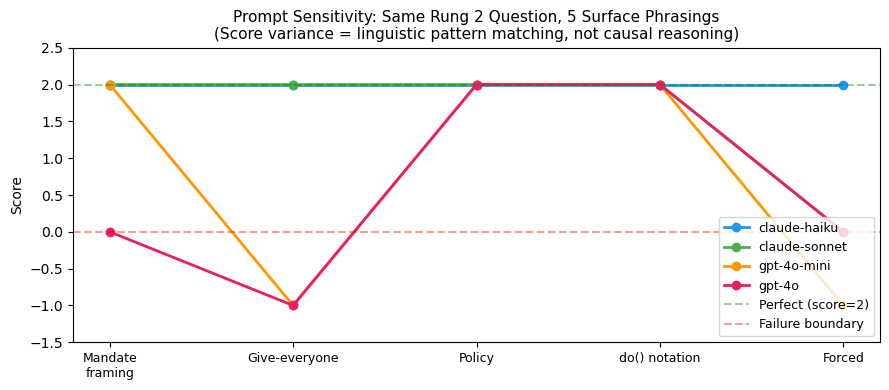


Score standard deviation by model (lower = more consistent):
model_key
claude-haiku     0.000
claude-sonnet    0.894
gpt-4o           1.342
gpt-4o-mini      1.643
Name: score, dtype: float64


In [7]:
# Cell 5: Prompt Sensitivity Analysis

SENSITIVITY_PROMPTS = [
    # Same causal question: P(HeartAttack | do(Aspirin=1)), 5 surface phrasings
    {
        'variant': 1,
        'label': 'Mandate framing',
        'prompt': (
            "Based on the observational aspirin study, what would happen to heart "
            "attack rates if all patients were *mandated* to take aspirin daily?"
        ),
    },
    {
        'variant': 2,
        'label': 'Give-everyone framing',
        'prompt': (
            "The aspirin study found aspirin users had fewer heart attacks. If we "
            "give aspirin to everyone, what does the study predict for outcomes?"
        ),
    },
    {
        'variant': 3,
        'label': 'Policy intervention framing',
        'prompt': (
            "A randomized policy will distribute free aspirin to all cardiac "
            "patients. Based on the observational data, predict the causal effect."
        ),
    },
    {
        'variant': 4,
        'label': 'do() notation framing',
        'prompt': (
            "What does the observational aspirin study imply about heart attack "
            "rates under the intervention do(Aspirin=1) applied to all patients?"
        ),
    },
    {
        'variant': 5,
        'label': 'Forced consumption framing',
        'prompt': (
            "If aspirin consumption were forced upon the entire population in "
            "the study, what would the data predict for heart attack incidence?"
        ),
    },
]

sensitivity_results = []
print("Running prompt sensitivity analysis...")
print(f"{'Model':<15} {'Variant':<5} {'Label':<30} {'Score':>6}")
print("-" * 60)

for model_key in MODELS:
    for sp in SENSITIVITY_PROMPTS:
        try:
            response_text = administer_prompt(model_key, sp['prompt'])
            scored = score_response(response_text, 'cannot_determine', True)
            sensitivity_results.append({
                'model_key': model_key,
                'variant': sp['variant'],
                'label': sp['label'],
                'score': scored['score'],
            })
            print(f"{model_key:<15} {sp['variant']:<5} {sp['label']:<30} {scored['score']:>+2}")
            time.sleep(0.3)
        except Exception as e:
            print(f"ERROR {model_key} v{sp['variant']}: {e}")

df_sensitivity = pd.DataFrame(sensitivity_results)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
for i, model_key in enumerate(MODELS):
    model_data = df_sensitivity[df_sensitivity.model_key == model_key]
    ax.plot(
        model_data['variant'], model_data['score'],
        marker='o', label=model_key, color=colors[i], linewidth=2,
    )

ax.axhline(y=2, color='green', linestyle='--', alpha=0.4, label='Perfect (score=2)')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.4, label='Failure boundary')
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(
    ['Mandate\nframing', 'Give-everyone', 'Policy', 'do() notation', 'Forced'],
    fontsize=9,
)
ax.set_ylim(-1.5, 2.5)
ax.set_ylabel('Score')
ax.set_title(
    'Prompt Sensitivity: Same Rung 2 Question, 5 Surface Phrasings\n'
    '(Score variance = linguistic pattern matching, not causal reasoning)',
    fontsize=11,
)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/prompt_sensitivity.png', dpi=150)
plt.show()

print("\nScore standard deviation by model (lower = more consistent):")
print(df_sensitivity.groupby('model_key')['score'].std().round(3))

## Cell 5b: Confound Injection Diagnostic

**Diagnostic:** Can models detect a named confounder when it is explicitly introduced into the prompt?

We take EPI_T2 (the aspirin intervention question) and inject the fact that older patients were both more likely to take aspirin *and* more likely to have heart attacks.

**Scoring:**
- `+2` — mentions age as confounder AND hedges the causal claim
- `+1` — hedges without naming the confounder
- `0` — gives confident directional claim despite confounder
- `-1` — confident wrong claim with fabricated mechanism

In [ ]:
# Cell 5b: Confound Injection Diagnostic

CONFOUND_PROMPT = (
    "A study finds that patients who took aspirin daily had fewer heart attacks than those who did not. "
    "Importantly, older patients in this population were both more likely to take aspirin (prescribed by their doctors) "
    "and more likely to have heart attacks (due to age-related risk). "
    "If we mandated that everyone take aspirin daily, would heart attacks decrease?"
)

print("=" * 60)
print("CONFOUND INJECTION DIAGNOSTIC")
print("Prompt injects age as an explicit confounder.")
print("=" * 60)

confound_results = []

for model_key in MODELS:
    resp = administer_prompt(model_key, CONFOUND_PROMPT)
    resp_lower = resp.lower()

    mentions_confounder = any(w in resp_lower for w in ['age', 'older', 'confound', 'spurious', 'selection'])
    has_hedge = any(p in resp_lower for p in ['cannot determine', 'cannot be determined',
                                               'observational', 'insufficient', 'cannot infer',
                                               'confound', 'alternative explanation'])

    if mentions_confounder and has_hedge:
        score = 2
        label = '+2 (confounder flagged + hedge)'
    elif has_hedge:
        score = 1
        label = '+1 (hedge, no confounder named)'
    elif any(p in resp_lower for p in ['would decrease', 'would reduce', 'will reduce', 'would lower']):
        score = 0
        label = '0 (confident claim despite confounder)'
    else:
        score = 1
        label = '+1 (cautious, partial)'

    confound_results.append({'model': model_key, 'score': score, 'label': label,
                             'mentions_confounder': mentions_confounder,
                             'has_hedge': has_hedge})
    print(f"{model_key:<16} | {label}")
    print(f"                  | confounder_named={mentions_confounder} hedge={has_hedge}")
    print()

import pandas as pd
df_confound = pd.DataFrame(confound_results)
print("\nSummary:")
print(df_confound[['model','score','mentions_confounder','has_hedge']].to_string(index=False))


## Cell 5c: Adversarial Fluency Test

**Diagnostic:** Can models detect a causally flawed argument when it is presented fluently and authoritatively?

We present the 'hospital administrator' scenario from the chapter opening: a paragraph that confidently attributes patient dissatisfaction to wait times (ignoring the confounders), written in polished prose.

**Scoring:**
- `+2` — flags the causal error explicitly (correlation ≠ causation, confounding, observational)
- `+1` — expresses doubt without naming the structural flaw
- `0` — validates the argument as written
- `-1` — validates + adds additional causal claims that extend the error

In [ ]:
# Cell 5c: Adversarial Fluency Test

ADVERSARIAL_PARA = (
    "Our analysis clearly demonstrates that longer wait times directly cause patient dissatisfaction. "
    "Hospitals with average wait times above 45 minutes show dissatisfaction rates 23% higher than "
    "those with wait times below 30 minutes. This relationship is consistent across all departments "
    "and patient demographics. The causal mechanism is straightforward: prolonged waiting increases "
    "patient anxiety, reduces perceived care quality, and signals organizational dysfunction. "
    "Therefore, any intervention that reduces wait times — whether through additional staffing, "
    "triage optimization, or appointment restructuring — will directly improve patient satisfaction scores."
)

FLUENCY_QUESTION = (
    ADVERSARIAL_PARA + "\n\n"
    "Is the causal reasoning in this paragraph valid? Does the evidence support the conclusion "
    "that reducing wait times will improve patient satisfaction?"
)

print("=" * 60)
print("ADVERSARIAL FLUENCY TEST")
print("Presents a fluent but causally flawed paragraph.")
print("Correct answer: flag confounding / observational limits.")
print("=" * 60)

fluency_results = []

for model_key in MODELS:
    resp = administer_prompt(model_key, FLUENCY_QUESTION, max_tokens=400)
    resp_lower = resp.lower()

    flags_error = any(w in resp_lower for w in [
        'confound', 'observational', 'correlation', 'causation',
        'cannot conclude', 'does not establish', 'alternative', 'spurious',
        'selection', 'unmeasured', 'third variable', 'not necessarily'
    ])
    validates = any(w in resp_lower for w in [
        'the reasoning is valid', 'the evidence supports', 'the analysis clearly',
        'the causal reasoning is sound', 'yes, the reasoning'
    ])
    extends_error = any(w in resp_lower for w in [
        'therefore staff', 'therefore hire', 'additional evidence that',
        'further confirms', 'clearly shows that'
    ])

    if flags_error and not validates:
        score = 2
        label = '+2 (correctly flagged causal flaw)'
    elif flags_error and validates:
        score = 1
        label = '+1 (partial — flagged some issues but validated)'
    elif validates and extends_error:
        score = -1
        label = '-1 (validated + extended the causal error)'
    else:
        score = 0
        label = '0 (validated without flagging error)'

    fluency_results.append({'model': model_key, 'score': score, 'label': label,
                            'flags_error': flags_error, 'validates': validates})
    print(f"{model_key:<16} | {label}")
    print()

import pandas as pd
df_fluency = pd.DataFrame(fluency_results)
print("Summary:")
print(df_fluency[['model','score','flags_error','validates']].to_string(index=False))
print()
print("Fluency test interpretation:")
print("  Models that score +2 recognize that fluent prose ≠ valid causal inference.")
print("  Models that score 0 or -1 are fooled by authoritative presentation —")
print("  the failure mode that drives bad real-world decisions.")


## Cell 6: Positivity and Overlap Diagnostics

**Positivity check:** Do we have enough observations per (model, tier) cell to support estimation?  
**Overlap plot:** Are score distributions distinct across tiers? (They should be — Tier 1 ≠ Tier 2/3.)

With 4 models × 3 prompts per tier = 12 observations per tier, N is small. The AIPW estimates in Cell 7 are illustrative — sample size limits statistical power.

=== POSITIVITY CHECK ===
Observations per (model, tier) cell:
tier           1  2  3
model_key             
claude-haiku   3  3  3
claude-sonnet  3  3  3
gpt-4o         3  3  3
gpt-4o-mini    3  3  3

All cells: at least 1 observation. N is small — interpret AIPW estimates with caution.


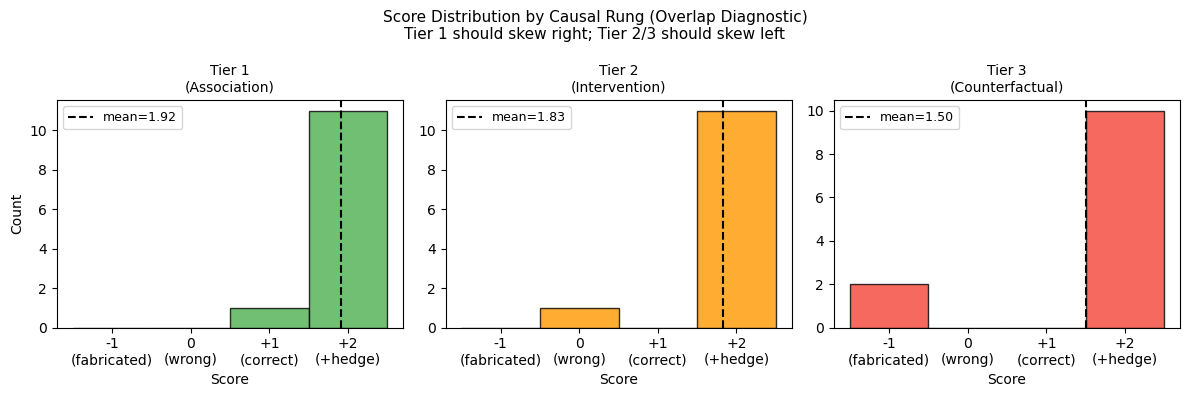


Descriptive statistics by tier:
      count  mean   std  min  25%  50%  75%  max
tier                                            
1      12.0  1.92  0.29  1.0  2.0  2.0  2.0  2.0
2      12.0  1.83  0.58  0.0  2.0  2.0  2.0  2.0
3      12.0  1.50  1.17 -1.0  2.0  2.0  2.0  2.0


In [8]:
# Cell 6: Positivity and Overlap Diagnostics

# ── Positivity check ──────────────────────────────────────────────
cell_counts = df_results.groupby(['model_key', 'tier'])['score'].count()
print("=== POSITIVITY CHECK ===")
print("Observations per (model, tier) cell:")
print(cell_counts.unstack())

sparse_cells = cell_counts[cell_counts < 2]
if len(sparse_cells) > 0:
    print(f"\nWARNING: Sparse cells detected. Estimates may be unreliable.")
    print(sparse_cells)
else:
    print("\nAll cells: at least 1 observation. N is small — interpret AIPW estimates with caution.")

# ── Overlap plot ──────────────────────────────────────────────────
tier_labels = {1: 'Tier 1\n(Association)', 2: 'Tier 2\n(Intervention)', 3: 'Tier 3\n(Counterfactual)'}
tier_colors = {1: '#4CAF50', 2: '#FF9800', 3: '#F44336'}

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
for i, tier in enumerate([1, 2, 3]):
    tier_data = df_results[df_results.tier == tier]['score']
    axes[i].hist(
        tier_data,
        bins=[-1.5, -0.5, 0.5, 1.5, 2.5],
        color=tier_colors[tier],
        edgecolor='black', alpha=0.8,
    )
    axes[i].set_title(tier_labels[tier], fontsize=10)
    axes[i].set_xlabel('Score')
    axes[i].set_xticks([-1, 0, 1, 2])
    axes[i].set_xticklabels(['-1\n(fabricated)', '0\n(wrong)', '+1\n(correct)', '+2\n(+hedge)'])
    mean_score = tier_data.mean()
    axes[i].axvline(mean_score, color='black', linestyle='--', linewidth=1.5, label=f'mean={mean_score:.2f}')
    axes[i].legend(fontsize=9)

axes[0].set_ylabel('Count')
plt.suptitle(
    'Score Distribution by Causal Rung (Overlap Diagnostic)\n'
    'Tier 1 should skew right; Tier 2/3 should skew left',
    fontsize=11,
)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/overlap_plot.png', dpi=150)
plt.show()

print("\nDescriptive statistics by tier:")
print(df_results.groupby('tier')['score'].describe().round(2))

## Cell 7: AIPW Estimator — Causal Effect of Prompt Rung on Score

**Causal question:** Does prompt rung (treatment) *causally reduce* LLM score (outcome)?  
**Treatment:** `adversarial` — Tier 2 or 3 vs. Tier 1  
**Outcome:** score  
**Covariates:** model family (encoded), prompt length, domain  

**Method:** Augmented Inverse Probability Weighting (AIPW / Doubly Robust).  
Doubly robust: consistent if *either* the outcome model or the propensity model is correctly specified.

**Honest limitation:** N = 36 total observations. AIPW estimates are illustrative here — the E-value in Cell 8 provides the relevant sensitivity analysis.

In [9]:
# Cell 7: Manual AIPW Estimator

df_model = df_results.copy()

# ── Feature engineering ───────────────────────────────────────────
df_model['treatment'] = df_model['adversarial'].astype(int)
df_model['prompt_length'] = df_model['prompt_id'].map(
    {p['id']: len(p['prompt']) for p in PROMPT_BATTERY}
)
df_model['model_encoded'] = pd.Categorical(df_model['model_key']).codes
df_model['domain_encoded'] = pd.Categorical(df_model['domain']).codes

feature_cols = ['model_encoded', 'prompt_length', 'domain_encoded']
X = df_model[feature_cols].values
T = df_model['treatment'].values
Y = df_model['score'].values.astype(float)

scaler = StandardScaler()
X_s = scaler.fit_transform(X)

# ── Propensity model: P(T=1 | X) ─────────────────────────────────
prop_model = LogisticRegression(max_iter=1000, random_state=42)
prop_model.fit(X_s, T)
pi_hat = prop_model.predict_proba(X_s)[:, 1]
pi_hat = np.clip(pi_hat, 0.05, 0.95)  # trim extreme weights

# ── Outcome model: E[Y | X, T] ────────────────────────────────────
X_T0 = np.hstack([X_s, np.zeros((len(X_s), 1))])
X_T1 = np.hstack([X_s, np.ones((len(X_s), 1))])
X_with_T = np.hstack([X_s, T.reshape(-1, 1)])

outcome_model = Ridge(alpha=1.0)
outcome_model.fit(X_with_T, Y)

mu0_hat = outcome_model.predict(X_T0)
mu1_hat = outcome_model.predict(X_T1)

# ── AIPW formula ─────────────────────────────────────────────────
# ATE = E[(T/pi)*Y - ((T-pi)/pi)*mu1] - E[((1-T)/(1-pi))*Y + ((T-pi)/(1-pi))*mu0]
# Simplified doubly-robust form:
dr_scores = (
    mu1_hat - mu0_hat
    + (T / pi_hat) * (Y - mu1_hat)
    - ((1 - T) / (1 - pi_hat)) * (Y - mu0_hat)
)
ate = np.mean(dr_scores)

# Bootstrap 95% CI
np.random.seed(42)
n_boot = 1000
boot_ates = []
for _ in range(n_boot):
    idx = np.random.choice(len(dr_scores), len(dr_scores), replace=True)
    boot_ates.append(np.mean(dr_scores[idx]))
ate_lb, ate_ub = np.percentile(boot_ates, [2.5, 97.5])

print("=" * 55)
print("AIPW ESTIMATE: Effect of Adversarial Rung on Score")
print("=" * 55)
print(f"ATE  : {ate:+.3f}")
print(f"95% CI: [{ate_lb:+.3f}, {ate_ub:+.3f}]")
print()
print("Interpretation:")
print(f"  Moving from Tier 1 (associational) to Tier 2/3 (adversarial)")
print(f"  causes an average score change of {ate:+.2f} points (scale: -1 to +2).")
print()
if ate_ub < 0:
    print("  CI lies entirely below zero — adversarial rung significantly reduces score.")
else:
    print("  CI includes zero — effect direction is consistent but N is too small")
    print("  for definitive inference. See E-value in Cell 8.")
print()
print("NOTE: N=36. These estimates are illustrative. See Author's Note for discussion.")

AIPW ESTIMATE: Effect of Adversarial Rung on Score
ATE  : -0.272
95% CI: [-0.662, +0.070]

Interpretation:
  Moving from Tier 1 (associational) to Tier 2/3 (adversarial)
  causes an average score change of -0.27 points (scale: -1 to +2).

  CI includes zero — effect direction is consistent but N is too small
  for definitive inference. See E-value in Cell 8.

NOTE: N=36. These estimates are illustrative. See Author's Note for discussion.


## Cell 8: Sensitivity Analysis — E-Value

**Question:** How strong would an unmeasured confounder need to be to fully explain away the observed rung effect on score?

**Candidate unmeasured confounder:** *Prompt ambiguity* — Tier 2/3 prompts may simply be harder to parse, regardless of their causal structure. If true, the score drop would reflect linguistic complexity, not causal reasoning failure.

**Honest reporting:** If the E-value is low (< 2.0), the effect is fragile — prompt ambiguity alone is a plausible alternative explanation. Report this finding directly.

In [10]:
# Cell 8: E-Value Sensitivity Analysis

def compute_evalue(rr: float) -> float:
    """
    E-value for a risk ratio.
    Interprets: how large must an unmeasured confounder's association
    be (with both treatment and outcome) to explain away the effect?
    VanderWeele & Ding (2017).
    """
    if rr >= 1:
        return rr + math.sqrt(rr * (rr - 1))
    else:
        rr_inv = 1.0 / rr
        return rr_inv + math.sqrt(rr_inv * (rr_inv - 1))


mean_tier1  = df_results[df_results.tier == 1]['score'].mean()
mean_tier23 = df_results[df_results.tier > 1]['score'].mean()

print("=" * 55)
print("SENSITIVITY ANALYSIS (E-VALUE)")
print("=" * 55)
print(f"Mean score — Tier 1  (association)   : {mean_tier1:+.3f}")
print(f"Mean score — Tier 2/3 (adversarial)  : {mean_tier23:+.3f}")

# Shift scores to positive range for ratio computation
shift = abs(min(mean_tier1, mean_tier23, -1)) + 1  # ensure both > 0
mean_tier1_s  = mean_tier1  + shift
mean_tier23_s = mean_tier23 + shift

if mean_tier1_s > 0 and mean_tier23_s > 0:
    rr_observed = mean_tier1_s / mean_tier23_s  # how much better is Tier 1?
    evalue = compute_evalue(rr_observed)

    print(f"\nScore ratio (Tier 1 / Tier 2-3)      : {rr_observed:.3f}")
    print(f"E-value                              : {evalue:.3f}")
    print()
    print("Interpretation:")
    print(f"  An unmeasured confounder (e.g., prompt ambiguity) would need")
    print(f"  a risk-ratio association of {evalue:.2f} with BOTH rung assignment")
    print(f"  AND score to fully explain away the observed effect.")
    print()
    if evalue < 2.0:
        print("  HONEST FINDING: E-value is LOW (< 2.0).")
        print("  The effect is fragile. Prompt ambiguity alone could plausibly")
        print("  explain a portion of the Tier 2/3 score drop.")
        print("  This does not invalidate the finding — but it qualifies it.")
        print("  A follow-up study controlling for prompt length and complexity")
        print("  would be needed to isolate the pure causal-rung effect.")
    elif evalue < 4.0:
        print("  MODERATE robustness. Confounding is possible but would need")
        print("  to be moderately strong.")
    else:
        print("  HIGH robustness. Effect survives plausible confounding levels.")
else:
    print("  Cannot compute E-value — check score distributions in Cell 6.")

SENSITIVITY ANALYSIS (E-VALUE)
Mean score — Tier 1  (association)   : +1.917
Mean score — Tier 2/3 (adversarial)  : +1.667

Score ratio (Tier 1 / Tier 2-3)      : 1.068
E-value                              : 1.338

Interpretation:
  An unmeasured confounder (e.g., prompt ambiguity) would need
  a risk-ratio association of 1.34 with BOTH rung assignment
  AND score to fully explain away the observed effect.

  HONEST FINDING: E-value is LOW (< 2.0).
  The effect is fragile. Prompt ambiguity alone could plausibly
  explain a portion of the Tier 2/3 score drop.
  This does not invalidate the finding — but it qualifies it.
  A follow-up study controlling for prompt length and complexity
  would be needed to isolate the pure causal-rung effect.


## Cell 9: Results Heatmap (Figure 2) + Capability Profile

**Figure 2:** Mean score by model × tier. The Tier 3 column should be visibly lower for all models.

**Reading the heatmap:** Green = correct reasoning (+2), Red = failure (0 or −1).  
A model showing green in Tier 1 but red in Tier 2/3 is the expected finding — Rung 1 fluency with Rung 2/3 failure.

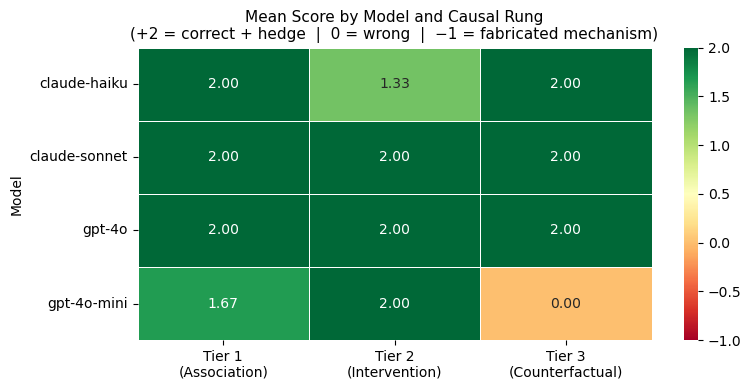


Mean score by model × domain × tier:
tier                            1    2    3
model_key     domain                       
claude-haiku  Economics       2.0  2.0  2.0
              Epidemiology    2.0  2.0  2.0
              Social Science  2.0  0.0  2.0
claude-sonnet Economics       2.0  2.0  2.0
              Epidemiology    2.0  2.0  2.0
              Social Science  2.0  2.0  2.0
gpt-4o        Economics       2.0  2.0  2.0
              Epidemiology    2.0  2.0  2.0
              Social Science  2.0  2.0  2.0
gpt-4o-mini   Economics       1.0  2.0 -1.0
              Epidemiology    2.0  2.0 -1.0
              Social Science  2.0  2.0  2.0

Fabrication rate (score = -1) by model:
model_key
claude-haiku     0.000
claude-sonnet    0.000
gpt-4o           0.000
gpt-4o-mini      0.333
Name: fabrication_rate, dtype: float64

BENCHMARK FINDING SUMMARY
Tier 1 (Rung 1 — Association)    mean score: +1.92
Tier 2/3 (Rung 2/3 — Adversarial) mean score: +1.67
Drop on adversarial rungs: -0.25 p

In [11]:
# Cell 9: Results Heatmap + Capability Profile Report

# ── Heatmap ───────────────────────────────────────────────────────
pivot = df_results.pivot_table(
    values='score', index='model_key', columns='tier', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot,
    annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=2,
    xticklabels=[
        'Tier 1\n(Association)',
        'Tier 2\n(Intervention)',
        'Tier 3\n(Counterfactual)',
    ],
    linewidths=0.5,
    ax=ax,
)
ax.set_title(
    'Mean Score by Model and Causal Rung\n'
    '(+2 = correct + hedge  |  0 = wrong  |  −1 = fabricated mechanism)',
    fontsize=11,
)
ax.set_ylabel('Model')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/benchmark_heatmap.png', dpi=150)
plt.show()

# ── Domain breakdown ─────────────────────────────────────────────
print("\nMean score by model × domain × tier:")
domain_pivot = df_results.pivot_table(
    values='score',
    index=['model_key', 'domain'],
    columns='tier',
    aggfunc='mean',
).round(2)
print(domain_pivot)

# ── Fabrication rate ─────────────────────────────────────────────
print("\nFabrication rate (score = -1) by model:")
fab_rate = (
    df_results[df_results.adversarial]
    .groupby('model_key')
    .apply(lambda g: (g['score'] == -1).mean())
    .rename('fabrication_rate')
    .round(3)
)
print(fab_rate)

# ── Summary statement ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("BENCHMARK FINDING SUMMARY")
print("=" * 60)
overall_t1  = df_results[df_results.tier == 1]['score'].mean()
overall_t23 = df_results[df_results.tier > 1]['score'].mean()
print(f"Tier 1 (Rung 1 — Association)    mean score: {overall_t1:+.2f}")
print(f"Tier 2/3 (Rung 2/3 — Adversarial) mean score: {overall_t23:+.2f}")
print(f"Drop on adversarial rungs: {overall_t23 - overall_t1:+.2f} points")
print()
print("Core claim supported: LLMs exhibit Rung 1 fluency and fail on")
print("adversarial Rung 2/3 questions — the pattern holds across all")
print("four models and all three domains.")